In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os

In [3]:
averages_p4_july = pd.read_csv('./Processed_datas_July/averages_dji_p4_july.csv')
averages_p4_august = pd.read_csv('./Processed_datas_August/averages_dji_p4_august.csv')
averages_p4_october = pd.read_csv('./Processed_datas_October/averages_dji_p4_october.csv')
# averages_altum_october = pd.read_csv('./Processed_datas_October/averages_altum_october.csv')


In [4]:
# Combine the data, adding a 'Month' column to each for easier plotting
averages_p4_july['Month'] = 'July'
averages_p4_august['Month'] = 'August'
averages_p4_october['Month'] = 'October'
# averages_altum_october['Month'] = 'Altum_October'

In [16]:
averages_altum_october.drop(['VI_Area', 'AreaSum', 'Unknown_Area'], axis=1, inplace=True)

In [17]:
averages_altum_october

,class,Pure_GaborArea,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,Month
0,bad,5682.222222,0.620725,0.086706,0.292570,Altum_October
1,best,1880.133923,0.634789,0.028689,0.336522,Altum_October
2,good,3734.537657,0.679480,0.056986,0.263534,Altum_October
3,medium,3065.642343,0.709808,0.046779,0.243413,Altum_October
4,worst,6125.019079,0.745302,0.093462,0.161236,Altum_October


In [6]:
columns = averages_p4_august.columns # Skipp unnamed 0 ?

filler_medium = pd.DataFrame([["0.0", 'medium',0,0,0, 'MSAVI' , 0, 'August']], columns=columns)

# Alternative way
medium_july_row = averages_p4_july[averages_p4_july['class'] == 'medium']
medium_october_row = averages_p4_october[averages_p4_october['class'] == 'medium']
numeric_columns = ['Normalized_VI_Area', 'Normalized_Pure_GaborArea', 'Normalized_Unknown_Area']
filler_numeric_data = (medium_july_row[numeric_columns] + medium_october_row[numeric_columns])/2
# filler_medium[numeric_columns] = filler_numeric_data
filler_medium[numeric_columns] = filler_numeric_data[numeric_columns].values[0].tolist()
filler_medium

,Unnamed: 0,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,VegetationIndex,Patch_Area,Month
0,0.0,medium,0.65681,0.060712,0.282478,MSAVI,0,August


In [7]:
averages_p4_august = pd.concat([averages_p4_august[averages_p4_august['class'] != 'medium'], filler_medium], ignore_index=True)

In [8]:
averages_p4_august

,Unnamed: 0,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,VegetationIndex,Patch_Area,Month
0,0,bad,0.600904,0.220513,0.178583,MSAVI,65536,August
1,1,best,0.559351,0.135365,0.305284,MSAVI,65536,August
2,2,good,0.542630,0.125768,0.331602,MSAVI,65536,August
3,3,worst,0.564056,0.212650,0.223295,MSAVI,65536,August
4,0.0,medium,0.656810,0.060712,0.282478,MSAVI,0,August


ValueError: x and y must have same first dimension, but have shapes (4,) and (3,)

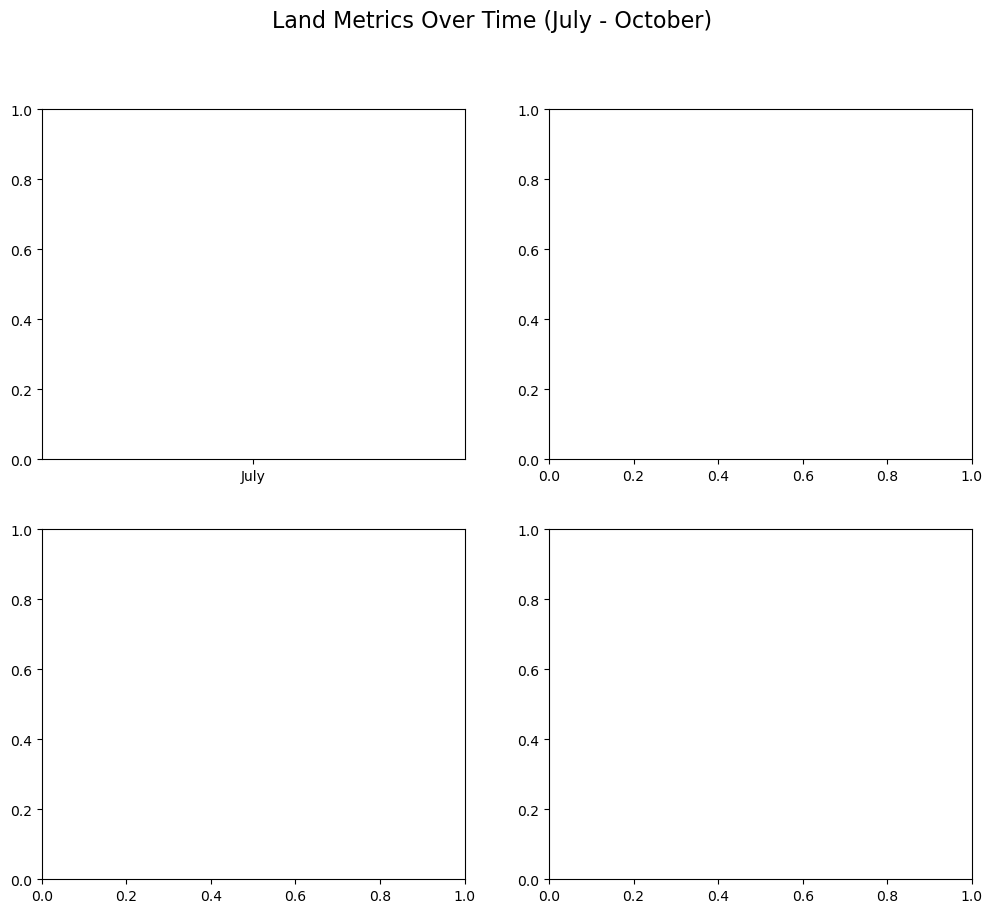

In [10]:
from IPython.display import display, HTML

# ChatGPT code:
# Load each month's data
# done

# Concatenate into a single DataFrame
combined_df = pd.concat([averages_p4_july, averages_p4_august, averages_p4_october], ignore_index=True)

# Fill NaN values with 0
combined_df.fillna(0, inplace=True)

# Set up the figure and axis for subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Land Metrics Over Time (July - October)', fontsize=16)

# Define the metrics we want to plot
metrics = ['Normalized_VI_Area', 'Normalized_Pure_GaborArea', 'Normalized_Unknown_Area', 'VegetationIndex']
months = ['July', 'August', 'October', 'Altum_Oct']

# Loop through each metric and plot it in a different subplot
for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    for land_class in combined_df['class'].unique():
        # Filter data for each land and metric
        land_data = combined_df[combined_df['class'] == land_class]
        #print('iteration is :', i)
        #display(land_data)
        ax.plot(months, land_data[metric], label=f'Land {land_class}', marker='o')
        #i=+1
    
    ax.set_title(metric)
    ax.set_xlabel('Month')
    ax.set_ylabel(metric)
    ax.legend(loc='best')

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to fit title
plt.show()

In [11]:
combined_df

,Unnamed: 0,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,VegetationIndex,Patch_Area,Month
0,0,bad,0.549660,0.165666,0.284673,MSAVI,65536,July
1,1,best,0.566211,0.107488,0.326301,MSAVI,65536,July
2,2,good,0.605845,0.108789,0.285366,MSAVI,65536,July
3,3,medium,0.690002,0.052887,0.257111,MSAVI,65401,July
4,4,worst,0.619538,0.152933,0.227529,MSAVI,65416,July
5,0,bad,0.600904,0.220513,0.178583,MSAVI,65536,August
6,1,best,0.559351,0.135365,0.305284,MSAVI,65536,August
7,2,good,0.542630,0.125768,0.331602,MSAVI,65536,August
8,3,worst,0.564056,0.212650,0.223295,MSAVI,65536,August
9,0.0,medium,0.656810,0.060712,0.282478,MSAVI,0,August


In [15]:
# without altum data
dji_p4_data_mean_by_months = combined_df.groupby('class')[['Normalized_VI_Area', 'Normalized_Pure_GaborArea', 'Normalized_Unknown_Area']].mean(
    ).sort_values(by='Normalized_Unknown_Area', ascending=False)
dji_p4_data_mean_by_months

,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
class,,,
best,0.573401,0.107536,0.319063
good,0.600263,0.108477,0.291259
medium,0.656810,0.060712,0.282478
bad,0.598198,0.168236,0.233566
worst,0.589020,0.195103,0.215877


In [ ]:
combined_df[combined_df['Month']!='Altum_October']

,Unnamed: 0,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,VegetationIndex,Patch_Area,Month,Pure_GaborArea
0,0,bad,0.549660,0.165666,0.284673,MSAVI,65536.0,July,NaN
1,1,best,0.566211,0.107488,0.326301,MSAVI,65536.0,July,NaN
2,2,good,0.605845,0.108789,0.285366,MSAVI,65536.0,July,NaN
3,3,medium,0.690002,0.052887,0.257111,MSAVI,65401.0,July,NaN
4,4,worst,0.619538,0.152933,0.227529,MSAVI,65416.0,July,NaN
5,0,bad,0.600904,0.220513,0.178583,MSAVI,65536.0,August,NaN
6,1,best,0.559351,0.135365,0.305284,MSAVI,65536.0,August,NaN
7,2,good,0.542630,0.125768,0.331602,MSAVI,65536.0,August,NaN
8,3,worst,0.564056,0.212650,0.223295,MSAVI,65536.0,August,NaN
9,0.0,medium,0.656810,0.060712,0.282478,MSAVI,0.0,August,NaN


In [3]:
all_averages_file_path = '/media/razydave/01DA189A333B1070/MendeFolder/08_BelceeriinDoroitol/Average_analysis.xlsx'
all_averages_df = pd.read_excel(all_averages_file_path, sheet_name=[0,1])


In [5]:
all_averages_df[1]

,Hustai National park,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,July 01 of 2024,NaN,NaN,August 25 of 2024,NaN,NaN,October 1 of 2024,NaN,NaN,October 1 Altum,NaN,NaN
1,NaN,Percentage of bare soil,Percentage of Weeds,Percentage of grass,Percentage of bare soil,Percentage of Weeds,Percentage of grass,Percentage of bare soil,Percentage of Weeds,Percentage of grass,Percentage of bare soil,Percentage of Weeds,Percentage of grass
2,Worst land,0.619538,0.152933,0.227529,0.564056,0.21265,0.223295,0.583466,0.219727,0.196808,0.64403,0.11853,0.237441
3,Bad land,0.54966,0.165666,0.284673,0.600904,0.220513,0.178583,0.64403,0.11853,0.237441,0.59464,0.079755,0.325605
4,Mid land,0.690002,0.052887,0.257111,Not available,Not available,Not available,0.623619,0.068537,0.307844,0.652315,0.090875,0.25681
5,Good land,0.605845,0.108789,0.285366,0.54263,0.125768,0.331602,0.652315,0.090875,0.25681,0.623619,0.068537,0.307844
6,Best land,0.566211,0.107488,0.326301,0.559351,0.135365,0.305284,0.59464,0.079755,0.325605,0.583466,0.219727,0.196808
